[150000. 198000. 246000. 294000. 342000.]


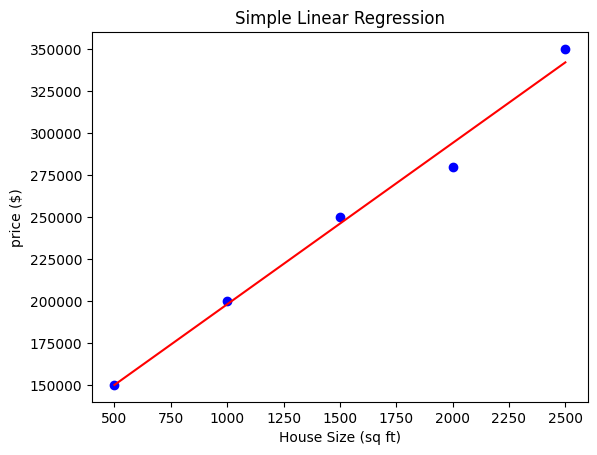

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
x = np.array([500, 1000, 1500, 2000, 2500]).reshape(-1,1)
y = np.array([150000, 200000, 250000, 280000, 350000])
model = LinearRegression()
model.fit(x,y)
y_pred = model.predict(x)
print (y_pred)
plt.scatter(x, y, color="blue")
plt.plot(x, y_pred, color="red")
plt.xlabel("House Size (sq ft)")
plt.ylabel("price ($)")
plt.title("Simple Linear Regression")
plt.show()

In [2]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
diabetes = load_diabetes(as_frame=True)
X = diabetes.data
y = diabetes.target
x_train, x_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MSE: 2900.1936284934814
R2: 0.4526027629719195


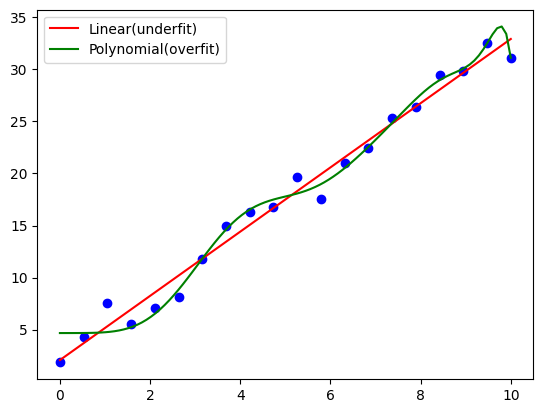

In [3]:
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
x =np.linspace(0, 10, 20).reshape(-1, 1)
y = 3*x.squeeze()+np.random.rand(20)*5
model_lin = LinearRegression().fit(x, y)
poly_model = make_pipeline(PolynomialFeatures(15), LinearRegression())
poly_model.fit(x, y)
x_test = np.linspace(0, 10, 100).reshape(-1, 1)
y_lin = model_lin.predict(x_test)
y_poly = poly_model.predict(x_test)
plt.scatter(x, y, color="blue")
plt.plot(x_test, y_lin, color="red", label="Linear(underfit)")
plt.plot(x_test, y_poly, color="green", label="Polynomial(overfit)")
plt.plot
plt.legend()
plt.show()

In [4]:

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report
iris = load_iris()
x = iris.data[iris.target != 2]
y = iris.target[iris.target != 2]
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2, random_state=42)
clf = LogisticRegression()
clf.fit(x_train, y_train)
y_pred = clf.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test,y_pred))
print("Classification Report:\n", classification_report(y_test,y_pred))

Accuracy: 1.0
Confusion Matrix:
 [[12  0]
 [ 0  8]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00         8

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [5]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_true = np.array([3, -0.5, 2, 7])
Y_pred = np.array([2.5, 0.0, 2, 8])
mse = mean_squared_error(y_true, Y_pred)
r2  = r2_score(y_true, Y_pred)
print("MSE:",mse,"R2:",r2)

MSE: 0.375 R2: 0.9486081370449679


In [7]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import numpy as np
y_true = [0,0,1,1,1,0,1,0,1,0]
y_pred = [0,0,1,0,1,0,1,1,1,0]
y_prob = [0.1,0.4,0.9,0.3,0.8,0.2,0.9,0.7,0.85,0.05]
print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
print("Report:\n", classification_report(y_true, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_true, y_prob))

Confusion Matrix:
 [[4 1]
 [1 4]]
Report:
               precision    recall  f1-score   support

           0       0.80      0.80      0.80         5
           1       0.80      0.80      0.80         5

    accuracy                           0.80        10
   macro avg       0.80      0.80      0.80        10
weighted avg       0.80      0.80      0.80        10

ROC-AUC Score: 0.92


In [8]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report
y_true = [0]*95 + [1]*5
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit([[0]]*100, y_true)
y_pred = dummy.predict([[0]]*100)
print("Accurate:", accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred))

Accurate: 0.95
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        95
           1       0.00      0.00      0.00         5

    accuracy                           0.95       100
   macro avg       0.47      0.50      0.49       100
weighted avg       0.90      0.95      0.93       100



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [9]:

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris
x, y = load_iris(return_X_y=True)
param_grid = {'n_estimators': [50, 100], 'max_depth':[2, 4, 6]}
grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=5, scoring='accuracy')
grid.fit(x, y)
print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Params: {'max_depth': 4, 'n_estimators': 100}
Best Score: 0.9666666666666668


In [10]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
param_dist = {'n_estimators': randint(50, 200), 'max_depth': randint(2, 10)}
random_search = RandomizedSearchCV(RandomForestClassifier(), param_dist, n_iter=10, cv=5, scoring='accuracy',random_state=42)
random_search.fit(x, y)
print("Best Params:", random_search.best_params_)

Best Params: {'max_depth': 8, 'n_estimators': 156}


In [11]:
from sklearn.model_selection import cross_val_score
import numpy as np
scores = cross_val_score(RandomForestClassifier(), x, y, cv=5, scoring='accuracy')
print("Cross-validation scores:",scores)
print("Mean Accuracy:",np.mean(scores))

Cross-validation scores: [0.96666667 0.96666667 0.93333333 0.96666667 1.        ]
Mean Accuracy: 0.9666666666666668
